In [1]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load dataset

df = pd.read_csv("ecommerce_customer_data_large.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [3]:
# 3. Basic dataset information

print("Shape:", df.shape)
df.info()
df.isnull().sum()

Shape: (250000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [4]:
# 4. Data cleaning

# Convert Purchase Date to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Fill missing values in Returns with 0
df['Returns'] = df['Returns'].fillna(0)

# Remove duplicate rows
df = df.drop_duplicates()

# Drop duplicate age column if both Age and Customer Age are same
df = df.drop(columns=['Age'])

# Check cleaned data
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,Female,0


In [5]:
# 5. Feature engineering

df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month
df['Day'] = df['Purchase Date'].dt.day_name()
df['Hour'] = df['Purchase Date'].dt.hour

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Gender,Churn,Year,Month,Day,Hour
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,Female,0,2023,5,Wednesday,21
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,Female,0,2021,5,Sunday,13
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,Female,0,2020,7,Monday,6
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,Female,0,2023,1,Tuesday,13
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,Female,0,2021,5,Saturday,11


In [6]:
# 6. Summary statistics

df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Churn,Year,Month,Hour
count,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000
mean,25017.632092,2021-11-06 19:26:22.286192384,254.742724,3.004936,2725.385196,43.798276,0.405904,0.20052,2021.377136,6.190376,11.510812
min,1.000000,2020-01-01 00:07:26,10.000000,1.000000,100.000000,18.000000,0.000000,0.00000,2020.000000,1.000000,0.000000
25%,12590.000000,2020-12-03 08:10:12,132.000000,2.000000,1476.000000,30.000000,0.000000,0.00000,2020.000000,3.000000,6.000000
50%,25011.000000,2021-11-06 07:39:08.500000,255.000000,3.000000,2725.000000,44.000000,0.000000,0.00000,2021.000000,6.000000,12.000000
75%,37441.250000,2022-10-11 01:21:56.249999872,377.000000,4.000000,3975.000000,57.000000,1.000000,0.00000,2022.000000,9.000000,18.000000
max,50000.000000,2023-09-13 18:42:49,500.000000,5.000000,5350.000000,70.000000,1.000000,1.00000,2023.000000,12.000000,23.000000
std,14412.515718,NaN,141.738104,1.414737,1442.576095,15.364915,0.491067,0.40039,1.074712,3.353238,6.921080


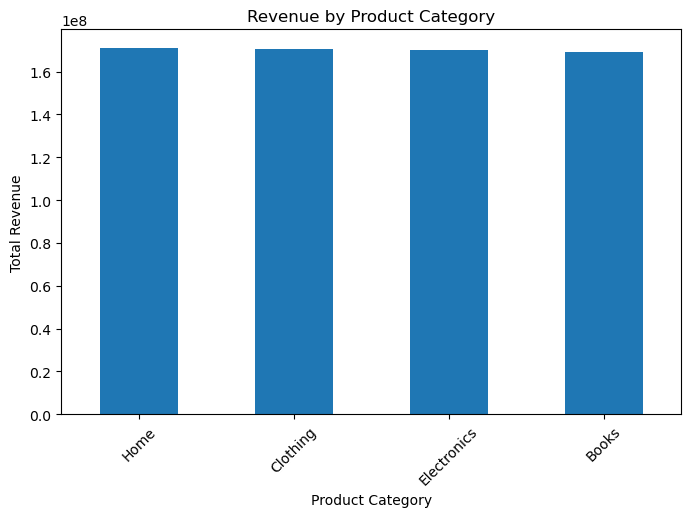

In [7]:
# 7. Revenue by product category

category_revenue = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar', figsize=(8,5))
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

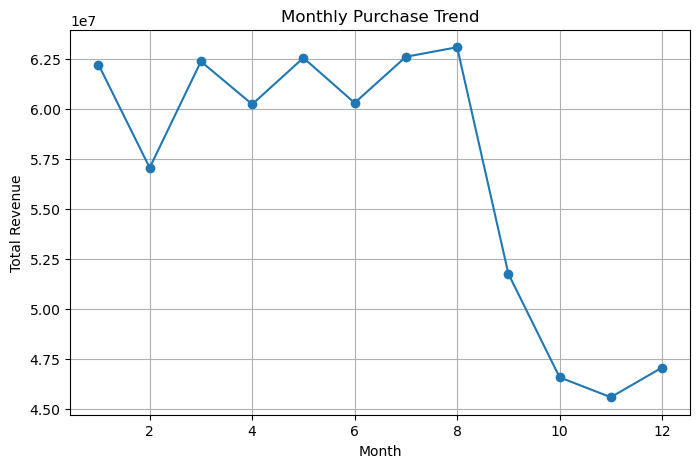

In [8]:
# 8. Monthly purchase trend

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

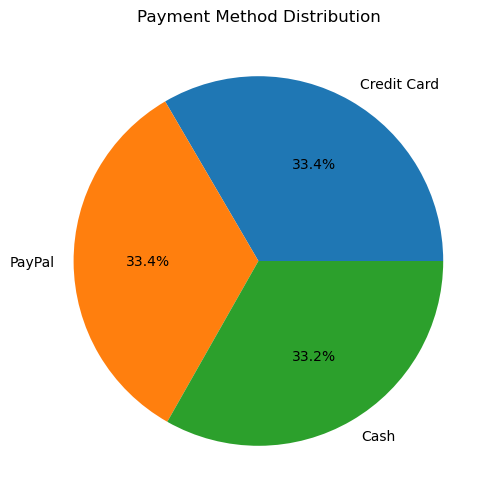

In [9]:
# 9. Payment method distribution

df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

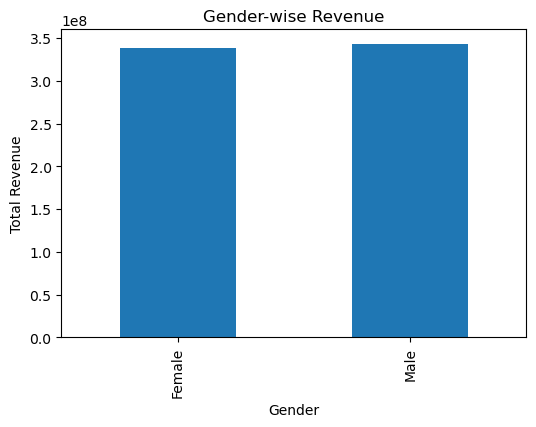

In [10]:
# 10. Gender-wise revenue

gender_revenue = df.groupby('Gender')['Total Purchase Amount'].sum()

gender_revenue.plot(kind='bar', figsize=(6,4))
plt.title('Gender-wise Revenue')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()

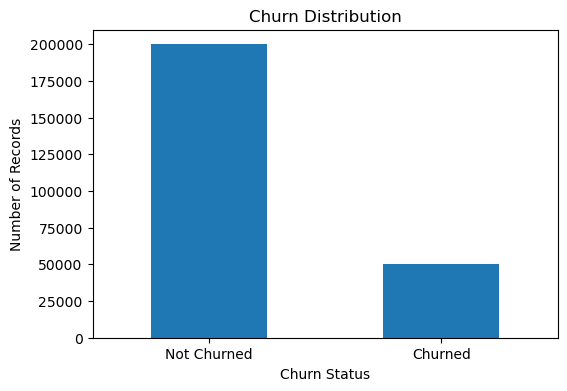

In [11]:
# 11. Churn distribution

df['Churn'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Records')
plt.xticks([0,1], ['Not Churned', 'Churned'], rotation=0)
plt.show()

In [12]:
# 12. RFM Analysis

reference_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (reference_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum',
    'Churn': 'max'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary', 'Churn']

rfm.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
1,289,3,6290,0
2,73,6,16481,0
3,223,4,9423,0
4,442,5,7826,0
5,425,5,9769,0


In [13]:
# 13. RFM scoring

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,Churn,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,,
1,289,3,6290,0,2,1,1,211
2,73,6,16481,0,4,3,3,433
3,223,4,9423,0,2,2,2,222
4,442,5,7826,0,1,2,1,121
5,425,5,9769,0,1,2,2,122


In [14]:
# 14. Customer segmentation

def segment_customer(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'High Value Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk Loyal Customers'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Churn Risk Customers'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Churn,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,,
1,289,3,6290,0,2,1,1,211,Churn Risk Customers
2,73,6,16481,0,4,3,3,433,High Value Customers
3,223,4,9423,0,2,2,2,222,Churn Risk Customers
4,442,5,7826,0,1,2,1,121,Churn Risk Customers
5,425,5,9769,0,1,2,2,122,Churn Risk Customers


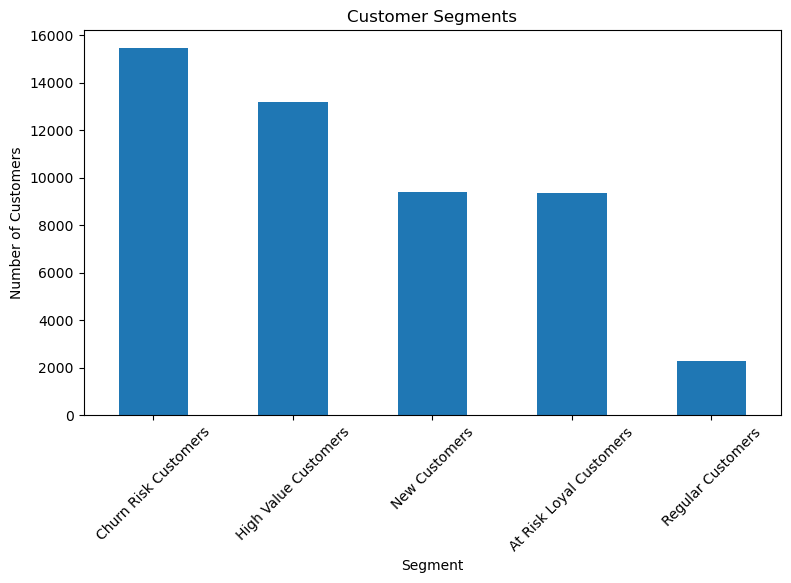

Segment
Churn Risk Customers       15446
High Value Customers       13178
New Customers               9385
At Risk Loyal Customers     9371
Regular Customers           2281
Name: count, dtype: int64

In [15]:
# 15. Segment count

segment_counts = rfm['Segment'].value_counts()

segment_counts.plot(kind='bar', figsize=(9,5))
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

segment_counts

In [16]:
# 16. Segment profile

segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Churn': 'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary,Churn
Segment,,,,
At Risk Loyal Customers,346.95,6.44,17572.06,0.20
Churn Risk Customers,499.44,3.13,8537.42,0.20
High Value Customers,79.30,7.20,20296.60,0.21
New Customers,88.09,3.61,9849.92,0.20
Regular Customers,83.45,5.55,10916.00,0.20


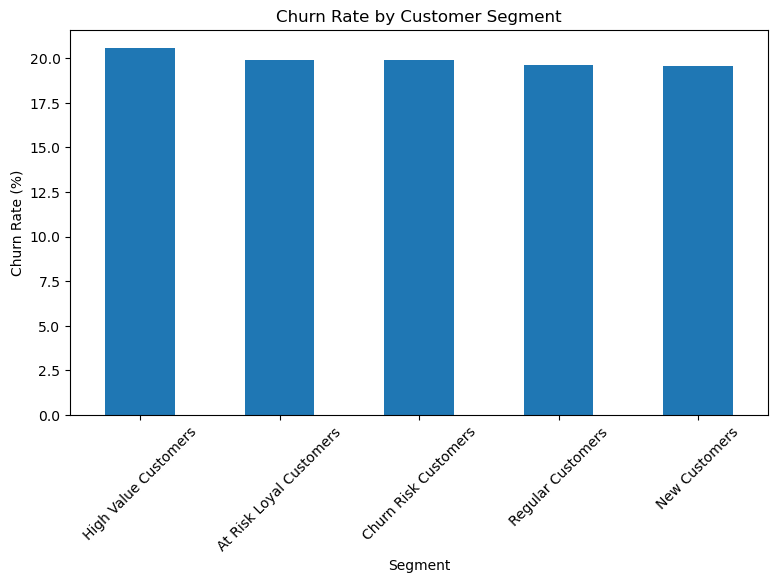

Segment
High Value Customers       20.556989
At Risk Loyal Customers    19.923167
Churn Risk Customers       19.882170
Regular Customers          19.640509
New Customers              19.541822
Name: Churn, dtype: float64

In [17]:
# 17. Churn rate by segment

churn_by_segment = rfm.groupby('Segment')['Churn'].mean().sort_values(ascending=False) * 100

churn_by_segment.plot(kind='bar', figsize=(9,5))
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

churn_by_segment

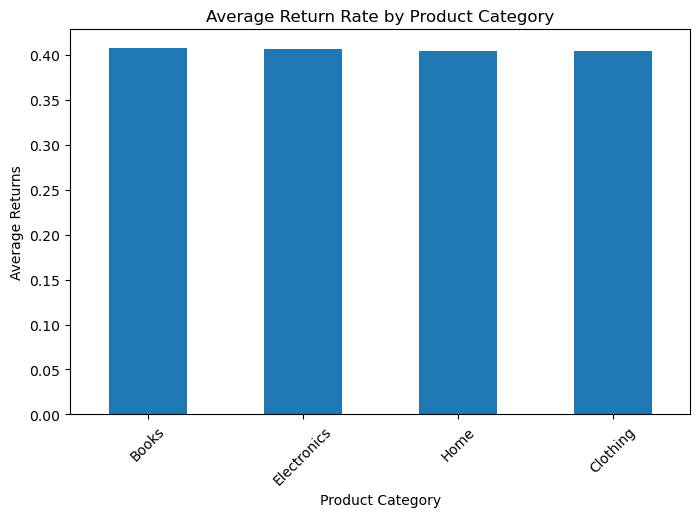

Product Category
Books          0.408148
Electronics    0.406323
Home           0.404848
Clothing       0.404308
Name: Returns, dtype: float64

In [18]:
# 18. Return rate by product category

return_rate = df.groupby('Product Category')['Returns'].mean().sort_values(ascending=False)

return_rate.plot(kind='bar', figsize=(8,5))
plt.title('Average Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Returns')
plt.xticks(rotation=45)
plt.show()

return_rate

In [19]:
# 19. Save final customer segmentation file

rfm.to_csv("customer_segments.csv")

print("Customer segmentation file saved successfully.")

Customer segmentation file saved successfully.


In [20]:
# 20. Final recommendations

recommendations = [
    "Offer personalized discounts to churn-risk customers to bring them back.",
    "Create loyalty rewards for high-value customers to increase retention.",
    "Promote top revenue-generating product categories through targeted campaigns.",
    "Analyze high-return product categories and improve product quality or descriptions.",
    "Send monthly engagement emails or WhatsApp offers based on customer purchase history."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Offer personalized discounts to churn-risk customers to bring them back.
2. Create loyalty rewards for high-value customers to increase retention.
3. Promote top revenue-generating product categories through targeted campaigns.
4. Analyze high-return product categories and improve product quality or descriptions.
5. Send monthly engagement emails or WhatsApp offers based on customer purchase history.
